In [29]:
import pyvisa                               # para comunicarnos con los equipos
import numpy as np                          # para operar con listas de datos
import pandas as pd                         # para manejar archivos de datos: Guardar, abrir, etc
import matplotlib.pyplot as plt             # para plotear 
import time                                 # para realizar pausas entre mediciones

rm = pyvisa.ResourceManager()

instrumentos_conectados = rm.list_resources()           # lista de instrumentos conectados

print (instrumentos_conectados)

gen = rm.open_resource('USB0::0xF4EC::0xEE38::SDG1XCA4161035::INSTR')                     # Establezco comunicación con el generador

gen.query('*IDN?')                                      # le pedimos que se identifique para checkear conexión

osci = rm.open_resource('USB0::0x0699::0x03C4::C041039::INSTR')                    # Establezco comunicación con el osciloscopio

osci.query('*IDN?')           
# le pido que se identifique para checkear la conexión


('USB0::0xF4EC::0xEE38::SDG1XCA4161035::INSTR', 'USB0::0x0699::0x03C4::C041039::INSTR', 'ASRL1::INSTR', 'ASRL10::INSTR')


'TEKTRONIX,TBS1102C,C041039,CF:91.1CT FV:v1.29.38; FPGA:v20.78; \n'

In [42]:
R = 97.9 #Ohms
C = 0.000001012 #Faradios
tau = R*C #s

taus = tau * np.array([0.01, 0.1, 1, 10, 100])

frecuencias = 1/taus

ts = []
VCH1s = []
VCH2s = []

escalas = np.array([])

1009338.398866311
2.641994666666667e-07
100933.83988663109
2.6419946666666672e-06
10093.38398866311
2.641994666666667e-05
1009.3383988663111
0.0002641994666666667
100.93383988663109
0.002641994666666667


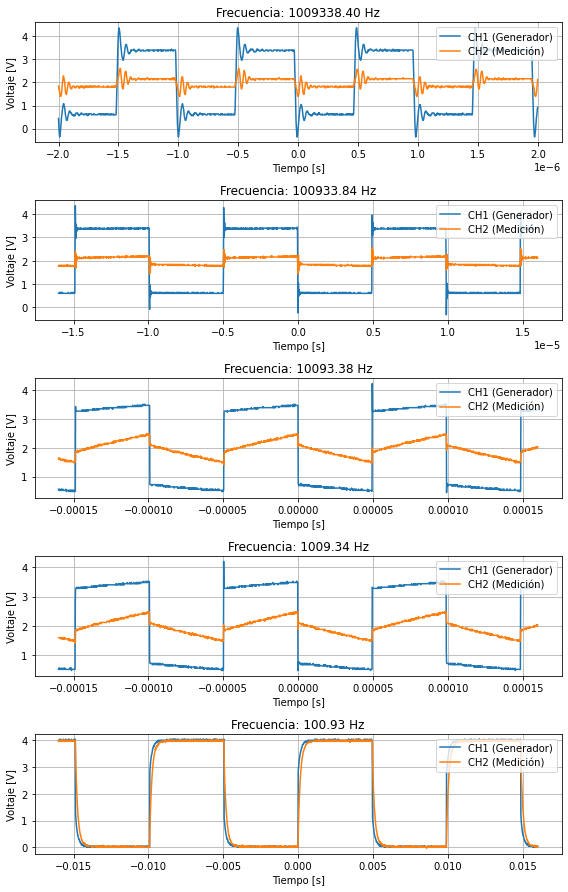

In [43]:
gen.write('C1:BSWV WVTP,SQUARE,AMP,4,OFST,2')

osci.write('DAT:ENC RPB')
osci.write('DAT:WID 1')         # data band width 1 byte
osci.write('HEADER OFF')

osci.write('SEL:CH1 ON')
osci.write('SEL:CH2 ON')

osci.write('CH1:SCA 1.0')
osci.write('CH2:SCA 1.0')

for i in range(len(frecuencias)):
    freq = frecuencias[i]
    print(freq)
    gen.write('C1:BSWV FRQ,%f' % freq)
    time.sleep(5)
    
    escala_horizontal = 4.0/ (15.0 * freq)
    print(escala_horizontal)
    osci.write('HOR:SCA %e' % escala_horizontal)
    time.sleep(5)      

    osci.write('ACQ:STATE OFF')
    time.sleep(0.5)
    
    osci.write('DAT:SOU CH1')
    xze1, xin1, yze1, ymu1, yoff1 = osci.query_ascii_values('WFMOUTPRE:XZE?;XIN?;YZE?;YMU?;YOFF?;', separator=';')
    time.sleep(5)
    dataCH1 = osci.query_binary_values('CURV?', datatype='B', container=np.array) 
    
    osci.write('DAT:SOU CH2')
    xze2, xin2, yze2, ymu2, yoff2 = osci.query_ascii_values('WFMOUTPRE:XZE?;XIN?;YZE?;YMU?;YOFF?;', separator=';')
    time.sleep(5)           
    dataCH2 = osci.query_binary_values('CURV?', datatype='B', container=np.array) 

    osci.write('ACQ:STATE ON')

    ts.append(xze1 + np.arange(len(dataCH1)) * xin1)
    VCH1s.append((dataCH1 - yoff1) * ymu1 + yze1)
    VCH2s.append((dataCH2 - yoff2) * ymu2 + yze2)
    
ts = np.array(ts)
VCH1s = np.array(VCH1s)
VCH2s = np.array(VCH2s)

dict1 = {}
dict2 = {}
for i, f in enumerate(frecuencias):
    dict1[f"t_f_{f:.1f}Hz"] = ts[i]
    dict1[f"V1_f_{f:.1f}Hz"] = VCH1s[i]
    dict2[f"t_f_{f:.1f}Hz"] = ts[i]
    dict2[f"V2_f_{f:.1f}Hz"] = VCH2s[i]

df1 = pd.DataFrame(dict1)
df1.to_csv("./voltaje_CH1s.csv", index=False)

df2 = pd.DataFrame(dict2)
df2.to_csv("./voltaje_CH2s.csv", index=False)

num_freqs = len(frecuencias)
fig, axes = plt.subplots(num_freqs, 1, figsize=(8, 2.5 * num_freqs), sharex=False)

if num_freqs == 1:
    axes = [axes]

for i, freq in enumerate(frecuencias):
    axes[i].plot(ts[i], VCH1s[i], label="CH1 (Generador)", color="tab:blue")
    axes[i].plot(ts[i], VCH2s[i], label="CH2 (Medición)", color="tab:orange")
    axes[i].set_title(f"Frecuencia: {freq:.2f} Hz")
    axes[i].set_xlabel("Tiempo [s]")
    axes[i].set_ylabel("Voltaje [V]")
    axes[i].grid(True)
    axes[i].legend(loc="upper right")

plt.tight_layout()
plt.show()